# Calour sample analysis notebook
This notebook uses the Chronic Fatigue Syndrome dataset from:

Giloteaux, Ludovic, et al., Microbiome 4.1 (2016): 30.
"Reduced diversity and altered composition of the gut microbiome in individuals with myalgic encephalomyelitis/chronic fatigue syndrome."

(See: https://microbiomejournal.biomedcentral.com/articles/10.1186/s40168-016-0171-4 )

But can be used for any amplicon experiment. Just need to provide a biom table and a mapping file.

### NOTE: full Calour documentation can be found [here](http://biocore.github.io/calour/)

The original notebook was developed for the Sheba/TAU microbiome analysis workshop (http://borensteinlab.com/events/microbiome_workshop/sandbox.html).

In [0]:
!pip install pyqt5

     |████████████████████████████████| 62.2MB 37kB/s 
     |████████████████████████████████| 266kB 47.2MB/s 


In [0]:
!pip install git+git://github.com/amnona/dbbact-calour 
!pip install scikit-bio docrep  biom-format

  Cloning git://github.com/amnona/dbbact-calour to /tmp/pip-req-build-icyp8ytj
  Running command git clone -q git://github.com/amnona/dbbact-calour /tmp/pip-req-build-icyp8ytj
  Created wheel for dbbact-calour: filename=dbbact_calour-0.1-cp36-none-any.whl size=28049148 sha256=2d729f7598fb2ae000a6b0a5ba4ed2a35f40ad7ea54baf8bdd6117028459cb30
  Stored in directory: /tmp/pip-ephem-wheel-cache-cuwcors3/wheels/38/6b/df/e30592057f13258d7cbd8c37574c1ef887e0f0fd53edd05752
Successfully built dbbact-calour
     |████████████████████████████████| 8.3MB 2.6MB/s 
     |████████████████████████████████| 11.8MB 23.6MB/s 
  Created wheel for scikit-bio: filename=scikit_bio-0.5.5-cp36-cp36m-linux_x86_64.whl size=1375709 sha256=02b3765a389c16b8cba9044f0198ef981a7ffe80c9bceb667f32dbaf318929d3
  Stored in directory: /root/.cache/pip/wheels/0d/e6/e6/427e994318de532b2e44b8bc975f26774087a204082f208100
  Created wheel for docrep: filename=docrep-0.2.7-cp36-none-any.whl size=23002 sha256=054f201f055cfb8f1606723

In [0]:
!pip install calour

     |████████████████████████████████| 92kB 2.8MB/s 
  Created wheel for calour: filename=calour-2018.5.1-cp36-none-any.whl size=98525 sha256=093a8a3454beb0d1e0820e4fb2a84ee98f0df9652613d3380050a5fccb30033d
  Stored in directory: /root/.cache/pip/wheels/ab/a2/e0/b12fe1f83f511b521768fd414ae7b6d618f8544a0fd660c89d
Successfully built calour


In [0]:
import calour as ca

# will disable "future warnings"
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd

import calour.database
db = calour.database._get_database_class('dbbact')


In [0]:
# Configure matplotlib figures 
%matplotlib inline
#%matplotlib notebook
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10, 8]

# Load the dataset
min_reads=1000 : throw away all samples with < 1000 reads

normalize=10000 : normalize total reads of each samples to 10000

(NOTE: this is not rarefaction - so samples with < 10000 reads will be streched to 10000 reads

Full function documentation [here](http://biocore.github.io/calour/generated/calour.io.read_amplicon.html#calour.io.read_amplicon)


In [0]:
from google.colab import drive
drive.mount('/content/drive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3aietf%3awg%3aoauth%3a2.0%3aoob&response_type=code&scope=email%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdocs.test%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive%20https%3a%2f%2fwww.googleapis.com%2fauth%2fdrive.photos.readonly%20https%3a%2f%2fwww.googleapis.com%2fauth%2fpeopleapi.readonly

Enter your authorization code:
··········
Mounted at /content/drive


# **YOU NEED TO UPLOAD THE FILES ("cfs.biom" and "cfs.map.txt") TO YOUR GOOGLE DRIVE AND ADJUST THE PATH IN THE NEXT CELL TO YOUR SYSTEM!** 
The files can be found here: http://borensteinlab.com/events/microbiome_workshop/files/

In [0]:
import biom
a = biom.load_table('/content/drive/My Drive/Colab Notebooks/data/cfs.biom')
# convert the biom data to a data-frame and rename the index field
# this might takes some minutes for larger files
df_test= a.to_dataframe()
df_test= df_test.transpose()
df_test.index.names= ['#SampleID']
df_test.head()

,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGACGCTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGGTGTCTTGAGTACAGTAGAGGCAGGCGGAATTCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGGTTGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGCGACCTTGAGTGCAACAGAGGTAGGCGGAATTCGTGG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGTGCGGCAAGTCTGATGTGAAAGCCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTCGTACTTGAGTATCGGAGAGGTAAGTGGAATTCCTAG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGATGGATGTTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGATATCTTGAGTGCAGTTGAGGCAGGCGGAATTCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGTGGATTGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGAAACTGGCAGTCTTGAGTACAGTAGAGGTGGGCGGAATTCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGATGGATGTTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGATGTCTTGAGTGCAGTTGAGGCAGGCGGAATTCGTGG,TACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTTTGTTAAGTCAGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATCTGATACTGGCAAGCTTGAGTCTCGTAGAGGGGGGTAGAATTCCAGG,AACGTAGGGTGCAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGCGCAGGCGGACCGGCAAGTTGGAAGTGAAAACTATGGGCTCAACCCATAAATTGCTTTCAAAACTGCTGGCCTTGAGTAGTGCAGAGGTAGGTGGAATTCCCGG,AACGTAGGGTGCAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGCGCAGGCGGGAAGACAAGTTGGAAGTGAAAACCATGGGCTCAACCCATGAATTGCTTTCAAAACTGTTTTTCTTGAGTAGTGCAGAGGTAGATGGAATTCCCGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGATTGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGCAGTCTTGAGTGCAGTAGAGGTGGGCGGAATTCGTGG,AACGTAGGTCACAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGCGCAGGCGGGAAGACAAGTTGGAAGTGAAATCTATGGGCTCAACCCATAAACTGCTTTCAAAACTGTTTTTCTTGAGTAGTGCAGAGGTAGGCGGAATTCCCGG,TACGTAGGGGGCGAGCGTTGTCCGGAATGATTGGGCGTAAAGGGCGTGTAGGCGGCTTTATAAGTCTGGAGTGAAAGTCCTGTTTTCAAGATGGGAATTGCTTTGGATACTGTAGGGCTTGAGTGCAGGAGAGGTTATCGGAATTCCCGG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGCGCAGCAAGTCTGATGTGAAAGGCAGGGGCTTAACCCCTGGACTGCATTGGAAACTGCTGTGCTTGAGTGCCGGAGGGGTAAGCGGAATTCCTAG,TACGGAGGATGCAAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGCACGCCAAGTCAGCGGTGAAATTTCCGGGCTCAACCCGGAGTGTGCCGTTGAAACTGGCGAGCTAGAGTACACAAGAGGCAGGCGGAATGCGTGG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGCATGATAAGTCTGATGTGAAAACCCAAGGCTCAACCATGGGACTGCATTGGAAACTGTCGTGCTGGAGTGTCGGAGAGGTGAGCGGAATTCCTAG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGCATGATAAGTCTGATGTGAAAACCCAAGGCTCAACCATGGGACTGCATTGGAAACTGTCGTGCTGGAGTGTCGGAGAGGTAAGCGGAATTCCTAG,TACGTAGGTGGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGAGCTGCAAGTCAGATGTGAAATCTCTGGGCTCAACCCAGAAACTGCATTTGAAACTGTAGCCCTTGAGTATCGGAGAGGCAAGCGGAATTCCTAG,TACGTAGGTCCCGAGCGTTGTCCGGATTTATTGGGCGTAAAGCGAGCGCAGGCGGTTTGATAAGTCTGAAGTTAAAGGCTGTGGCTCAACCATAGTTCGCTTTGGAAACTGTCAAACTTGAGTGCAGAAGGGGAGAGTGGAATTCCATGT,TACGTAGGGAGCGAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGCGTAGGCGGGATAGCAAGTCAGATGTGAAAACTATGGGCTCAACCTGTAGATTGCATTTGAAACTGTTGTTCTTGAGTGAAGTAGAGGTAAGCGGAATTCCTAG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGACTGGCAAGTCTGATGTGAAAGGCGGGGGCTCAACCCCTGGACTGCATTGGAAACTGTTAGTCTTGAGTGCCGGAGAGGTAAGCGGAATTCCTAG,TACGGAAGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGGCTTTTAAGTCAGCGGTCAAATGTCACGGCTCAACCGTGGCCAGCCGTTGAAACTGTAAGCCTTGAGTCTGCACAGGGCACATGGAATTCGTGGT,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGTGTGGCAAGTCTGATGTGAAAGGCATGGGCTCAACCTGTGGACTGCATTGGAAACTGTCATACTTGAGTGCCGGAGGGGTAAGCGGAATTCCTAG,TACGGAGGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGCACGCCAAGTCAGCGGTGAAATTTCCGGGCTCAACCCGGAGTGTGCCGTTGAAACTGGCGAGCTAGAGTACACAAGAGGCAGGCGGAATGCGTGG,TACGTAGGTGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGGAGTGCAAGTCAGATGTGAAAACTATGGGCTCAACCCATAGCCTGCATTTGAAACTGTACTTCTTGAGTGATGGAGAGGCAGGCGGAATTCCCTG,TACGGAGGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGTGGTGATTTAAGTCAGCGGTGAAAGTTTGTGGCTCAACCATAAAATTGCCGTTGAAACTGGGTTACTTGAGTGTGTTTGAGGTAGGCGGAATGCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGTGGATTGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGAAACTGGGAGTCTTGAGTACAGTAGAGGTGGGCGGAATTCGTGG,TACGTAGGTGGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGTGCAGCCGGGCATGCAAGTCAGATGTG

In [0]:
dat = ca.read_amplicon('/content/drive/My Drive/Colab Notebooks/data/cfs.biom','/content/drive/My Drive/Colab Notebooks/data/cfs.map.txt',
                       normalize=10000,min_reads=1000)

2019-12-01 13:29:56 WARNING These have metadata but do not have data - dropped: {'ERR1331814'}


We load samples and features to create Calour's data structure that each samples containing counts of features. Furthurmore, we remove all samples with less than min_readsm, and normalize each sample to the specified count.

## What do we have
NOTE: "features" means "bacteria" for amplicon data

In [0]:
print(dat)

AmpliconExperiment ("cfs.biom") with 87 samples, 2129 features


### Also lets see the sample_metadata (mapping file) columns
The sample metadata is stored as a pandas dataframe

In [0]:
print(dat.feature_metadata.columns)

Index(['_feature_id', 'taxonomy'], dtype='object')


In [0]:
dat.sample_metadata.head()

,Sample_Name_s,collection_date_s,environment_biome_s,environmental_package_s,geographic_location_country_and_or_sea_s,Pittsburgh,Energy_fatigue,sCD14ugml,Sex,IFABPpgml,General_health,LBPugml,Social_functioning,Role_emotio0l,LPSpgml,Subject,Emotio0l_well_being,Role_physical,Bell,Physical_functioning,Pain,Age,BMI,_sample_id,_calour_original_abundance
#SampleID,,,,,,,,,,,,,,,,,,,,,,,,,
ERR1331798,LR16,2012-12/2013-09,Feces,human-gut,USA,3,0,1.47,Female,296.7,35,22.70,13.0,0.0,131.60,Patient,72,0.0,20,75,23.0,50,37.59,ERR1331798,62629.0
ERR1331812,LR72,2012-12/2013-09,Feces,human-gut,USA,1,15,1.78,Male,517.5,20,26.01,0.0,NaN,122.20,Patient,56,NaN,30,60,68.0,64,22.85,ERR1331812,96404.0
ERR1331836,LR42,2012-12/2013-09,Feces,human-gut,USA,0,0,1.48,Female,482.7,0,10.23,0.0,0.0,53.62,Control,0,0.0,0,0,0.0,35,30.66,ERR1331836,105470.0
ERR1331831,IC10,2012-12/2013-09,Feces,human-gut,USA,0,0,1.68,Female,488.1,0,18.29,0.0,0.0,75.65,Control,0,0.0,0,0,0.0,45,22.24,ERR1331831,50560.0
ERR1331815,LR75,2012-12/2013-09,Feces,human-gut,USA,0,0,2.11,Male,845.1,0,34.52,0.0,0.0,201.34,Patient,0,0.0,0,0,0.0,41,32.30,ERR1331815,66414.0


In [0]:
print(dat.sample_metadata.columns)

Index(['Sample_Name_s', 'collection_date_s', 'environment_biome_s',
       'environmental_package_s', 'geographic_location_country_and_or_sea_s',
       'Pittsburgh', 'Energy_fatigue', 'sCD14ugml', 'Sex', 'IFABPpgml',
       'General_health', 'LBPugml', 'Social_functioning', 'Role_emotio0l',
       'LPSpgml', 'Subject', 'Emotio0l_well_being', 'Role_physical', 'Bell',
       'Physical_functioning', 'Pain', 'Age', 'BMI', '_sample_id',
       '_calour_original_abundance'],
      dtype='object')


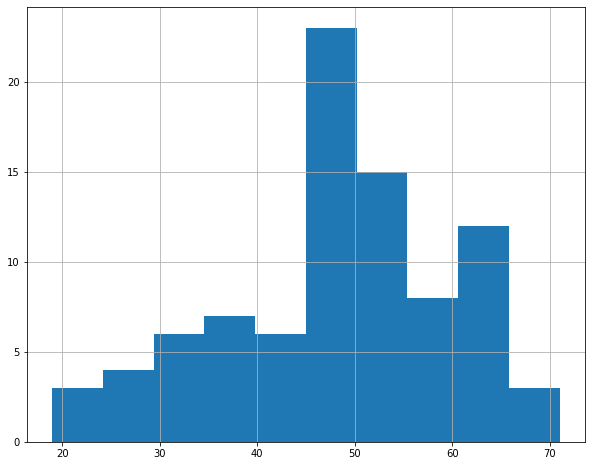

In [0]:
dat.sample_metadata['Age'].hist()

See an age distribution across the control and pateint group. The age majority of this group is greater than 45 years old.




# Remove low abundance bacteria
we remove all bacteria with sum of reads < 10 reads total over all samples.

A tutorial notebook dealing with data manipulation is located [here](http://biocore.github.io/calour/notebooks/microbiome_manipulation.html)

In [0]:
dat = dat.filter_abundance(10)

In [0]:
print(dat)

AmpliconExperiment ("cfs.biom") with 87 samples, 1100 features


In [0]:
dat.to_pandas().head()

,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGACGCTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGGTGTCTTGAGTACAGTAGAGGCAGGCGGAATTCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGGTTGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGCGACCTTGAGTGCAACAGAGGTAGGCGGAATTCGTGG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGTGCGGCAAGTCTGATGTGAAAGCCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTCGTACTTGAGTATCGGAGAGGTAAGTGGAATTCCTAG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGATGGATGTTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGATATCTTGAGTGCAGTTGAGGCAGGCGGAATTCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGTGGATTGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGAAACTGGCAGTCTTGAGTACAGTAGAGGTGGGCGGAATTCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGATGGATGTTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGATGTCTTGAGTGCAGTTGAGGCAGGCGGAATTCGTGG,TACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTTTGTTAAGTCAGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATCTGATACTGGCAAGCTTGAGTCTCGTAGAGGGGGGTAGAATTCCAGG,AACGTAGGGTGCAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGCGCAGGCGGACCGGCAAGTTGGAAGTGAAAACTATGGGCTCAACCCATAAATTGCTTTCAAAACTGCTGGCCTTGAGTAGTGCAGAGGTAGGTGGAATTCCCGG,AACGTAGGGTGCAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGCGCAGGCGGGAAGACAAGTTGGAAGTGAAAACCATGGGCTCAACCCATGAATTGCTTTCAAAACTGTTTTTCTTGAGTAGTGCAGAGGTAGATGGAATTCCCGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGATTGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGCAGTCTTGAGTGCAGTAGAGGTGGGCGGAATTCGTGG,AACGTAGGTCACAAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGCGCAGGCGGGAAGACAAGTTGGAAGTGAAATCTATGGGCTCAACCCATAAACTGCTTTCAAAACTGTTTTTCTTGAGTAGTGCAGAGGTAGGCGGAATTCCCGG,TACGTAGGGGGCGAGCGTTGTCCGGAATGATTGGGCGTAAAGGGCGTGTAGGCGGCTTTATAAGTCTGGAGTGAAAGTCCTGTTTTCAAGATGGGAATTGCTTTGGATACTGTAGGGCTTGAGTGCAGGAGAGGTTATCGGAATTCCCGG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGCGCAGCAAGTCTGATGTGAAAGGCAGGGGCTTAACCCCTGGACTGCATTGGAAACTGCTGTGCTTGAGTGCCGGAGGGGTAAGCGGAATTCCTAG,TACGGAGGATGCAAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGCACGCCAAGTCAGCGGTGAAATTTCCGGGCTCAACCCGGAGTGTGCCGTTGAAACTGGCGAGCTAGAGTACACAAGAGGCAGGCGGAATGCGTGG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGCATGATAAGTCTGATGTGAAAACCCAAGGCTCAACCATGGGACTGCATTGGAAACTGTCGTGCTGGAGTGTCGGAGAGGTGAGCGGAATTCCTAG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGCATGATAAGTCTGATGTGAAAACCCAAGGCTCAACCATGGGACTGCATTGGAAACTGTCGTGCTGGAGTGTCGGAGAGGTAAGCGGAATTCCTAG,TACGTAGGTGGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGAGCTGCAAGTCAGATGTGAAATCTCTGGGCTCAACCCAGAAACTGCATTTGAAACTGTAGCCCTTGAGTATCGGAGAGGCAAGCGGAATTCCTAG,TACGTAGGTCCCGAGCGTTGTCCGGATTTATTGGGCGTAAAGCGAGCGCAGGCGGTTTGATAAGTCTGAAGTTAAAGGCTGTGGCTCAACCATAGTTCGCTTTGGAAACTGTCAAACTTGAGTGCAGAAGGGGAGAGTGGAATTCCATGT,TACGTAGGGAGCGAGCGTTGTCCGGAATTACTGGGTGTAAAGGGAGCGTAGGCGGGATAGCAAGTCAGATGTGAAAACTATGGGCTCAACCTGTAGATTGCATTTGAAACTGTTGTTCTTGAGTGAAGTAGAGGTAAGCGGAATTCCTAG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGACTGGCAAGTCTGATGTGAAAGGCGGGGGCTCAACCCCTGGACTGCATTGGAAACTGTTAGTCTTGAGTGCCGGAGAGGTAAGCGGAATTCCTAG,TACGGAAGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGGCTTTTAAGTCAGCGGTCAAATGTCACGGCTCAACCGTGGCCAGCCGTTGAAACTGTAAGCCTTGAGTCTGCACAGGGCACATGGAATTCGTGGT,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGTGTGGCAAGTCTGATGTGAAAGGCATGGGCTCAACCTGTGGACTGCATTGGAAACTGTCATACTTGAGTGCCGGAGGGGTAAGCGGAATTCCTAG,TACGGAGGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGCACGCCAAGTCAGCGGTGAAATTTCCGGGCTCAACCCGGAGTGTGCCGTTGAAACTGGCGAGCTAGAGTACACAAGAGGCAGGCGGAATGCGTGG,TACGTAGGTGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGGAGTGCAAGTCAGATGTGAAAACTATGGGCTCAACCCATAGCCTGCATTTGAAACTGTACTTCTTGAGTGATGGAGAGGCAGGCGGAATTCCCTG,TACGGAGGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGTGGTGATTTAAGTCAGCGGTGAAAGTTTGTGGCTCAACCATAAAATTGCCGTTGAAACTGGGTTACTTGAGTGTGTTTGAGGTAGGCGGAATGCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGTGGATTGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGAAACTGGGAGTCTTGAGTACAGTAGAGGTGGGCGGAATTCGTGG,TACGTAGGTGGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGTGCAGCCGGGCATGCAAGTCAGATGTG

we remove all bacteria with sum of reads < 10 reads compared to total over all samples after each sample was normalized to 10000 reads/sample. 

# Cluster the bacteria

In [0]:
dat = dat.cluster_features()
dat.to_pandas()

,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGTGGACAGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGCTGTCTTGAGTACAGTAGAGGTGGGCGGAATTCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGATGGATGTTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGATATCTTGAGTGCAGTTGAGGCAGGCGGAATTCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGACTATTAAGTCAGCTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGTCGTCTTGAGTGCAGTAGAGGTAGGCGGAATTCGTGG,TACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTTTGTTAAGTCAGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATCTGATACTGGCAAGCTTGAGTCTCGTAGAGGGGGGTAGAATTCCAGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGTGGATTGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGAAACTGGCAGTCTTGAGTACAGTAGAGGTGGGCGGAATTCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGATGGATGTTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGATGTCTTGAGTGCAGTTGAGGCAGGCGGAATTCGTGG,TACGGAGGATCCAAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGTTTGATAAGTTAGAGGTGAAATACCGGGGCTCAACTCCGGAACTGCCTCTAATACTGTTGAACTAGAGAGTAGTTGCGGTAGGCGGAATGTATGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGTGGACTGGTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGTCAGTCTTGAGTACAGTAGAGGTGGGCGGAATTCGTGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGACGCTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGGTGTCTTGAGTACAGTAGAGGCAGGCGGAATTCGTGG,TACGTAGGTGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGGAAGGCAAGTCAGATGTGAAAACTATGGGCTCAACCCATAGCCTGCATTTGAAACTGTTTTTCTTGAGTGCTGGAGAGGCAATCGGAATTCCGTG,TACGGAGGATTCAAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGTTTGATAAGTTAGAGGTGAAATCCCGGGGCTTAACTCCGGAACTGCCTCTAATACTGTTAGACTAGAGAGTAGTTGCGGTAGGCGGAATGTATGG,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGCCTTTTAAGTCAGCGGTGAAAGTCTGTGGCTCAACCATAGAATTGCCGTTGAAACTGGGAGGCTTGAGTATGTTTGAGGCAGGCGGAATGCGTGG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGTTTTGCAAGTCTGAAGTGAAAGCCCGGGGCTTAACCCCGGGACTGCTTTGGAAACTGTAGAACTAGAGTGCAGGAGAGGTAAGTGGAATTCCTAG,TACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGTACGGCAAGTCTGATGTGAAATCCCGGGGCTCAACCCCGGTACTGCATTGGAAACTGTCGGACTAGAGTGTCGGAGGGGTAAGTGGAATTCCTAG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGCATGATAAGTCTGATGTGAAAACCCAAGGCTCAACCATGGGACTGCATTGGAAACTGTCGTGCTGGAGTGTCGGAGAGGTAAGCGGAATTCCTAG,TACGTATGGAGCAAGCGTTATCCGGATTTATTGGGCGTAAAGCGCGCGTAGGCGGCTTGTTAAGCAAGGTCTTAAATCTTGGGGCTCAACCTCAAGCCGGATCTTGAACTGGCAGGCTCGAGTATGGTAGAGGAAAGTGGAATTCCCAGT,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGATTGTTAAGTCAGTTGTGAAAGTTTGCGGCTCAACCGTAAAATTGCAGTTGATACTGGCAGTCTTGAGTGCAGTAGAGGTGGGCGGAATTCGTGG,TACGTAGGGAGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGTGCGTAGGCGGCTAGGCAAGTCAGACGTGAAAACCATGGGCTCAACCTGTGGACTGCGTTTGAAACTGTTTAGCTTGAGTGAAGTAGAGGTAGGCGGAATTCCCGG,TACGTAGGTGGCAAGCGTTGTCCGGAATTATTGGGCGTAAAGCGCGCGCAGGCGGCTTCCCAAGTCCCTCTTAAAAGTGCGGGGCTTAACCCCGTGATGGGAAGGAAACTGGGAAGCTGGAGTATCGGAGAGGAAAGTGGAATTCCTAGT,TACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGCAGGCGGAAGGCTAAGTCTGATGTGAAAGCCCGGGGCTCAACCCCGGTACTGCATTGGAAACTGGTCATCTAGAGTGTCGGAGGGGTAAGTGGAATTCCTAG,TACGGAGGATGCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGTGGTGATTTAAGTCAGCGGTGAAAGTTTGTGGCTCAACCATAAAATTGCCGTTGAAACTGGGTTACTTGAGTGTGTTTGAGGTAGGCGGAATGCGTGG,TACGTAGGGTGCGAGCGTTAATCGGAATTACTGGGCGTAAAGGGTGCGCAGGCGGTTGAGTAAGACAGATGTGAAATCCCCGAGCTTAACTCGGGAATGGCATATGTGACTGCTCGACTAGAGTGTGTCAGAGGGAGGTGGAATTCCACG,TACGGAGGGTGCAAGCGTTAATCGGAATTACTGGGCGTAAAGCGCACGCAGGCGGTCTGTCAAGTCGGATGTGAAATCCCCGGGCTCAACCTGGGAACTGCATTCGAAACTGGCAGGCTAGAGTCTTGTAGAGGGGGGTAGAATTCCAGG,TACGTAGGGTGCAAGCGTTATCCGGAATTATTGGGCGTAAAGGGCTCGTAGGCGGTTCGTCGCGTCCGGTGTGAAAGTCCATCGCTTAACGGTGGATCCGCGCCGGGTACGGGCGGGCTTGAGTGCGGTAGGGGAGACTGGAATTCCCGG,TACGTAGGGGGCAAGCGTTATCCGGAATTACTGGGTGTAAAGGGTGAGTAGGCGGCATGGCAAGTAAGATGTGAAAGCCCGAGGCTTAACCTCGGGATTGCATTTTAAACTGCTAAGCTAGAGTACAGGAGAGGAAAGCGGAATTCCTAG,TACGTAGGTGGCGAGCGTTGTCCGGAATTATTGGGCGTAAAGAGCATGTAGGCGGCTTAATAAGTCGAGCGTGAAAATGCGGGGCTCAACCCCGTATGGCGCTGGAAACTGTTAGGCTTGAGTGCAGGAGAGGAAAGGGGAATTCCCAGT,TACGGAGGATCCGAGCGTTATCCGGATTTATTGGGTTTAAAGGGAGCGTAGGCGGGTGCTTAAGTCAGTTGTG

"cluster_features" method is applied which apply log transforming, and scaling on features.




# Sort the samples according to the sick/healthy column

In [0]:
#dat = dat.sort_samples('Subject')
dat.sample_metadata

,Sample_Name_s,collection_date_s,environment_biome_s,environmental_package_s,geographic_location_country_and_or_sea_s,Pittsburgh,Energy_fatigue,sCD14ugml,Sex,IFABPpgml,General_health,LBPugml,Social_functioning,Role_emotio0l,LPSpgml,Subject,Emotio0l_well_being,Role_physical,Bell,Physical_functioning,Pain,Age,BMI,_sample_id,_calour_original_abundance
#SampleID,,,,,,,,,,,,,,,,,,,,,,,,,
ERR1331798,LR16,2012-12/2013-09,Feces,human-gut,USA,3,0,1.47,Female,296.7,35,22.70,13.0,0.0,131.60,Patient,72,0.0,20,75,23.0,50,37.59,ERR1331798,62629.0
ERR1331812,LR72,2012-12/2013-09,Feces,human-gut,USA,1,15,1.78,Male,517.5,20,26.01,0.0,NaN,122.20,Patient,56,NaN,30,60,68.0,64,22.85,ERR1331812,96404.0
ERR1331836,LR42,2012-12/2013-09,Feces,human-gut,USA,0,0,1.48,Female,482.7,0,10.23,0.0,0.0,53.62,Control,0,0.0,0,0,0.0,35,30.66,ERR1331836,105470.0
ERR1331831,IC10,2012-12/2013-09,Feces,human-gut,USA,0,0,1.68,Female,488.1,0,18.29,0.0,0.0,75.65,Control,0,0.0,0,0,0.0,45,22.24,ERR1331831,50560.0
ERR1331815,LR75,2012-12/2013-09,Feces,human-gut,USA,0,0,2.11,Male,845.1,0,34.52,0.0,0.0,201.34,Patient,0,0.0,0,0,0.0,41,32.30,ERR1331815,66414.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ERR1331818,IC04,2012-12/2013-09,Feces,human-gut,USA,0,0,1.64,Male,572.1,0,13.23,0.0,0.0,97.45,Control,0,0.0,0,0,0.0,32,32.98,ERR1331818,71017.0
ERR1331792,LR09,2012-12/2013-09,Feces,human-gut,USA,1,60,1.62,Female,151.3,60,14.23,50.0,100.0,64.14,Control,24,100.0,90,80,65.0,43,22.14,ERR1331792,41598.0
ERR1331857,IC8,2012-12/2013-09,Feces,human-gut,USA,0,0,1.81,Male,160.0,0,10.20,0.0,0.0,41.23,Control,0,0.0,0,0,0.0,53,29.02,ERR1331857,89919.0


In [0]:
dat = dat.sort_samples('Subject')
dat.sample_metadata

,Sample_Name_s,collection_date_s,environment_biome_s,environmental_package_s,geographic_location_country_and_or_sea_s,Pittsburgh,Energy_fatigue,sCD14ugml,Sex,IFABPpgml,General_health,LBPugml,Social_functioning,Role_emotio0l,LPSpgml,Subject,Emotio0l_well_being,Role_physical,Bell,Physical_functioning,Pain,Age,BMI,_sample_id,_calour_original_abundance
#SampleID,,,,,,,,,,,,,,,,,,,,,,,,,
ERR1331836,LR42,2012-12/2013-09,Feces,human-gut,USA,0,0,1.48,Female,482.7,0,10.23,0.0,0.0,53.62,Control,0,0.0,0,0,0.0,35,30.66,ERR1331836,105470.0
ERR1331831,IC10,2012-12/2013-09,Feces,human-gut,USA,0,0,1.68,Female,488.1,0,18.29,0.0,0.0,75.65,Control,0,0.0,0,0,0.0,45,22.24,ERR1331831,50560.0
ERR1331854,LR51,2012-12/2013-09,Feces,human-gut,USA,0,0,1.85,Female,0.0,0,12.32,0.0,0.0,105.92,Control,0,0.0,0,0,0.0,46,28.34,ERR1331854,59655.0
ERR1331820,IC06,2012-12/2013-09,Feces,human-gut,USA,0,0,0.98,Female,806.0,0,10.43,0.0,0.0,65.55,Control,0,0.0,0,0,0.0,47,24.36,ERR1331820,106959.0
ERR1331827,IC15,2012-12/2013-09,Feces,human-gut,USA,0,0,1.34,Female,173.0,0,12.32,0.0,0.0,47.09,Control,0,0.0,0,0,0.0,48,25.92,ERR1331827,41310.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ERR1331811,LR73,2012-12/2013-09,Feces,human-gut,USA,2,27,1.94,Male,278.3,20,30.54,25.0,0.0,134.98,Patient,36,25.0,50,50,33.0,39,28.66,ERR1331811,63968.0
ERR1331832,LR46,2012-12/2013-09,Feces,human-gut,USA,1,5,3.02,Female,577.9,15,33.30,25.0,100.0,143.43,Patient,72,0.0,30,56,23.0,65,37.20,ERR1331832,49032.0
ERR1331859,LR54,2012-12/2013-09,Feces,human-gut,USA,3,50,2.24,Female,0.0,10,16.80,0.0,100.0,54.43,Patient,76,0.0,30,15,10.0,63,25.79,ERR1331859,77150.0


Sort the samples according to the subject  column (Control / Patient)

# And plot the data
### For full information about the plot function, see [here](http://biocore.github.io/calour/generated/calour.heatmap.plot.html#calour.heatmap.plot)

### interactive heatmap inside the notebook
Can click on a row/column to get information,

2019-12-01 13:30:00 WARNING You need to set up jupyter notebook with `%matplotlib notebook`


Label(value='0 features are selected')

HTML(value='no annotation found', layout=Layout(height='100px', overflow_y='auto'))

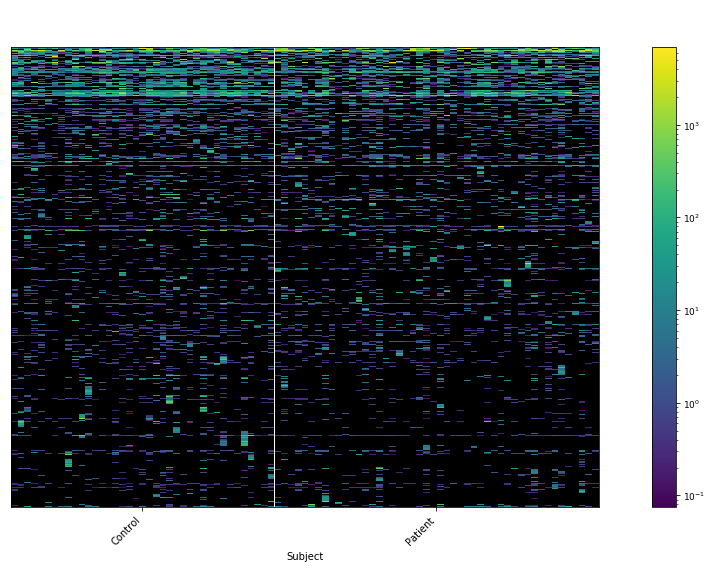

In [0]:
dat.plot(gui='jupyter', sample_field='Subject')

# Get differentially abundant bacteria
between sick ('Patient') and healthy ('Control')

A tutorial notebook dealing with differential abundance can be found [here](http://biocore.github.io/calour/notebooks/microbiome_diff_abundance.html)

In [0]:
dd=dat.diff_abundance('Subject','Patient','Control', random_seed=42)

In [0]:
print('there are %d bacteria significantly different between the two groups' % len(dd.feature_metadata))


there are 59 bacteria significantly different between the two groups


In [0]:
dd.feature_metadata.head()

,_feature_id,taxonomy,_calour_diff_abundance_effect,_calour_diff_abundance_pval,_calour_diff_abundance_group
TACGTAGGGGGCGAGCGTTATCCGGATTCATTGGGCGTAAAGCGCGCGTAGGCGGCCCGGCAGGCCGGGGGTCGAAGCGGGGGGCTCAACCCCCCGAAGCCCCCGGAACCTCCGCGGCTTGGGTCCGGTAGGGGAGGGTGGAACACCCGG,TACGTAGGGGGCGAGCGTTATCCGGATTCATTGGGCGTAAAGCGCG...,NA,-21.331731,0.000999,Control
TACGTAGGGGGCGAGCGTTGTCCGGAATGATTGGGCGTAAAGGGCGCGTAGGCGGCCTGCTAAGTCTGGAGTGAAAGTCCTGCTTTCAAGGTGGGAATTGCTTTGGATACTGGTGGGCTGGAGTGCAGGAGAGGAAAGCGGAATTACCGG,TACGTAGGGGGCGAGCGTTGTCCGGAATGATTGGGCGTAAAGGGCG...,NA,-20.588141,0.000999,Control
TACGTAGGTGGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCGTGCAGCCGGGTCTGCAAGTCAGATGTGAAATCCATGGGCTCAACCCATGAACTGCATTTGAAACTGTAGATCTTGAGTGTCGGAGGGGCAATCGGAATTCCTAG,TACGTAGGTGGCAAGCGTTGTCCGGATTTACTGGGTGTAAAGGGCG...,NA,-17.939103,0.001998,Control
TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGCATAACAAGTCTGATGTGAAAGGCTGGGGCTTAACCCCGGGACTGCATTGGAAACTGTTAAGCTTGAGTGCCGGAGGGGTAAGCGGAATTCCTAG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAG...,NA,-17.497596,0.002997,Control
TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGCTTTGCAAGTCTGACGTGAAACTCCGGGGCTCAACTCCGGAACTGCGTTGGAAACTGTAAGGCTTGAGTGCCGGAGAGGTAAGCGGAATTCCTAG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAG...,NA,-17.474359,0.002997,Control


In [0]:
#dd.sort_samples('Subject')
#dataframe_patient = dd.feature_metadata._calour_diff_abundance_group["dd.feature_metadata._calour_diff_abundance_group" == "Patient"]
#dataframe_patient
#print(dd.feature_metadata['_calour_direction' == "Patient"])
df = dd.feature_metadata

df_patient =df[(df['_calour_diff_abundance_group'] == "Patient")] 
#df_patient.sort_values('_calour_diff_abundance_effect').head()
df_patient.sort_values(['_calour_diff_abundance_effect', '_calour_diff_abundance_pval'], ascending=[False, True]).head()
#_calour_diff_abundance_effect	_calour_diff_abundance_pval 

# Eggerthella lenta -Actinobacteria
# TACGTAGGGAGCGAGCGTTATCCGGATTCATTGGGCGTAAAGAGCGCGTAGGCGGCCTCTCAAGCGGGATCTCTAATCCGAGGGCTCAACCCCCGGCCGGATCCCGAACTGGGAGGCTCGAGTTCGGTAGAGGCAGGCGGAATTCCCGGT

# Flavonifractor plautii -Firmicutes
# TACGTAGGTGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGGATTGCAAGTCAGATGTGAAAACTGGGGGCTCAACCTCCAGCCTGCATTTGAAACTGTAGTTCTTGAGTGCTGGAGAGGCAATCGGAATTCCGTG

#  Clostridium glycyrrhizinilyticum -Firmicutes
#TACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGAGAGGCAAGTCTGATGTGAAAACCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTTTTTCTAGAGTGTCGGAGAGGTAAGTGGAATTCCTAG

# Eggerthella lenta TACGTAGGGAGCGAGCGTTATCCGGATTCATTGGGCGTAAAGAGCGCGTAGGCGGCCTCTCAAGCGGGATCTCTAATCCGAGGGCTCAACCCCCGGCCGGATCCCGAACTGGGAGGCTCGAGTTCGGTAGAGGCAGGCGGAATTCCCGGT
# Clostridium glycyrrhizinilyticum TACGTAGGGGGCGAGCGTTGTCCGGAATGATTGGGCGTAAAGGGCGCGTAGGCGGCCTGCTAAGTCTGGAGTGAAAGTCCTGCTTTCAAGGTGGGAATTGCTTTGGATACTGGTGGGCTGGAGTGCAGGAGAGGAAAGCGGAATTACCGG
# Erysipelatoclostridium ramosum TACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGAGGGAGCAGGCGGCAGCAAGGGTCTGTGGTGAAAGCCTGAAGCTTAACTTCAGTAAGCCATAGAAACCAGGCAGCTAGAGTGCAGGAGAGGATCGTGGAATTCCATGT

,_feature_id,taxonomy,_calour_diff_abundance_effect,_calour_diff_abundance_pval,_calour_diff_abundance_group
TACGTAGGGAGCGAGCGTTATCCGGATTCATTGGGCGTAAAGAGCGCGTAGGCGGCCTCTCAAGCGGGATCTCTAATCCGAGGGCTCAACCCCCGGCCGGATCCCGAACTGGGAGGCTCGAGTTCGGTAGAGGCAGGCGGAATTCCCGGT,TACGTAGGGAGCGAGCGTTATCCGGATTCATTGGGCGTAAAGAGCG...,NA,21.889423,0.000999,Patient
TACGTAGGTGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGCGTGTAGGCGGGATTGCAAGTCAGATGTGAAAACTGGGGGCTCAACCTCCAGCCTGCATTTGAAACTGTAGTTCTTGAGTGCTGGAGAGGCAATCGGAATTCCGTG,TACGTAGGTGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGCG...,NA,20.588141,0.000999,Patient
TACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGAGAGGCAAGTCTGATGTGAAAACCCGGGGCTCAACCCCGGGACTGCATTGGAAACTGTTTTTCTAGAGTGTCGGAGAGGTAAGTGGAATTCCTAG,TACGTATGGTGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAG...,NA,18.403846,0.000999,Patient
TACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGAGGGAGCAGGCGGCAGCAAGGGTCTGTGGTGAAAGCCTGAAGCTTAACTTCAGTAAGCCATAGAAACCAGGCAGCTAGAGTGCAGGAGAGGATCGTGGAATTCCATGT,TACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGAGGG...,NA,18.125000,0.000999,Patient
TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAGCGTAGACGGAGCAGCAAGTCTGATGTGAAAGGCGGGGGCTCAACCCCCGGACTGCATTGGAAACTGTTGATCTTGAGTACCGGAGAGGTAAGCGGAATTCCTAG,TACGTAGGGGGCAAGCGTTATCCGGATTTACTGGGTGTAAAGGGAG...,NA,16.126603,0.002997,Patient


## Plotting the differentially abundant bacteria
We add the y-axis colorbar for the group in which the bacteria was high ('_calour_diff_abundance_group')

Note diff_abundance sorts the different bacteria according to the effect size

2019-12-01 13:30:01 WARNING You need to set up jupyter notebook with `%matplotlib notebook`


Label(value='0 features are selected')

HTML(value='no annotation found', layout=Layout(height='100px', overflow_y='auto'))

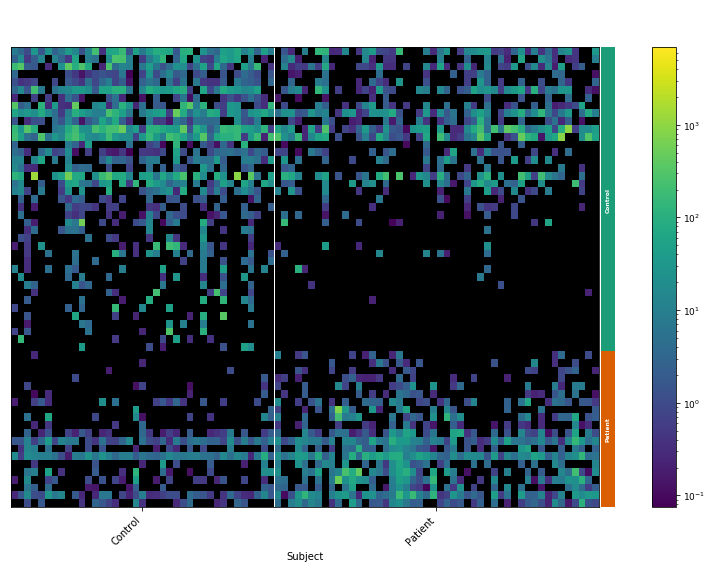

In [0]:
dd.plot(gui='jupyter', sample_field='Subject', bary_fields=['_calour_diff_abundance_group'])

# Looking at dbbact annotations
A tutorial notebook for dbBact interfacing can be found [here](http://biocore.github.io/calour/notebooks/microbiome_databases.html)

You will need the [dbbact-calour](https://github.com/amnona/dbbact-calour) module to be installed in the same conda environment as calour in order to use these functions.
See Calour installation instructions [here](https://github.com/biocore/calour/blob/master/INSTALL.md)

In [0]:
# !pip install git+git://github.com/amnona/dbbact-calour

## Enriched terms between the two groups

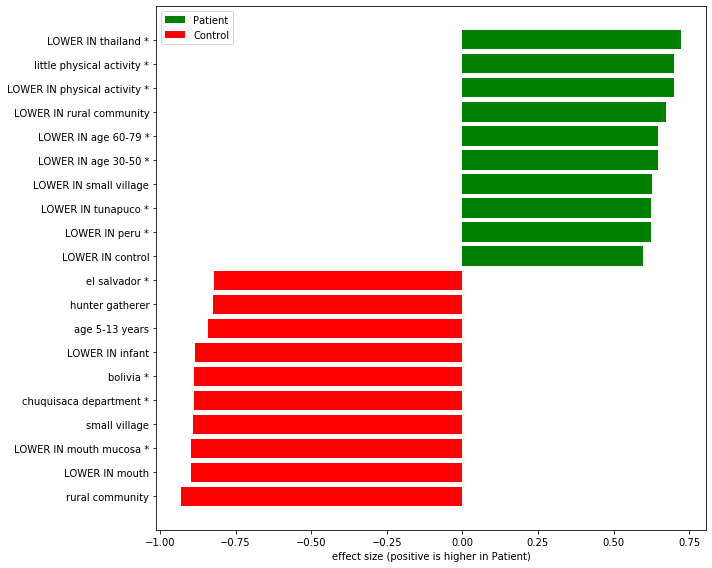

In [0]:
ax, enriched= dd.plot_diff_abundance_enrichment()

In [0]:
enriched.feature_metadata

,term,odif,pvals,num_enriched_exps,num_total_exps
rural community,rural community,-0.929487,0.000999,-1.0,-1.0
LOWER IN mouth,LOWER IN mouth,-0.897436,0.000999,-1.0,-1.0
LOWER IN mouth mucosa *,LOWER IN mouth mucosa *,-0.897436,0.000999,-1.0,-1.0
small village,small village,-0.891026,0.000999,-1.0,-1.0
chuquisaca department *,chuquisaca department *,-0.888462,0.000999,-1.0,-1.0
...,...,...,...,...,...
LOWER IN age 60-79 *,LOWER IN age 60-79 *,0.646154,0.000999,-1.0,-1.0
LOWER IN rural community,LOWER IN rural community,0.671795,0.000999,-1.0,-1.0
little physical activity *,little physical activity *,0.700000,0.000999,-1.0,-1.0
LOWER IN physical activity *,LOWER IN physical activity *,0.700000,0.000999,-1.0,-1.0


## Venn diagram for the "small village" term

In [0]:
db=ca.database._get_database_class('dbbact')

In [0]:
dd.feature_metadata['_calour_direction'] = dd.feature_metadata._calour_diff_abundance_group

2019-12-01 13:30:12 WARNING No experiment found matching the details [['DataMD5', '99966db551ad04955c849cf018db31d9'], ['MapMD5', '88f1851e51864c653fd2a13d5c5d3fb8']]
2019-12-01 13:30:12 WARNING No matching experiment found in dbBact. Not ignoring any experiments


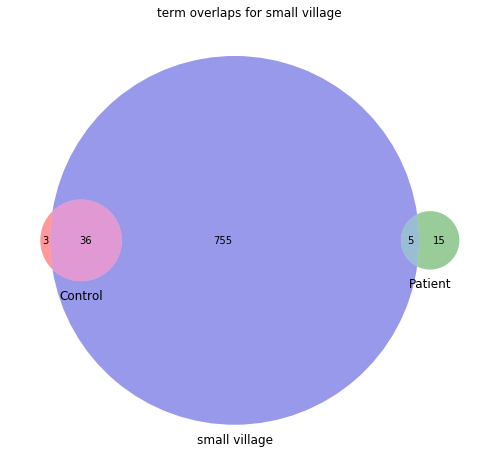

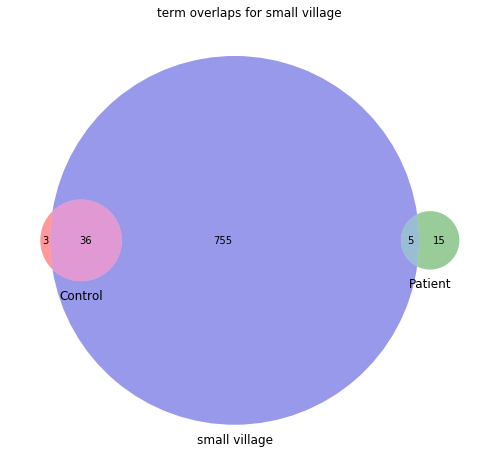

In [0]:
db.plot_term_venn_all(['small village'], dd, ignore_exp=True)

## heatmap for annotations containing "small village"
NOTE: here columns are bacteria, rows are annotations (sorted by experiment, which is the y-axis colorbar)

2019-12-01 13:30:16 WARNING You need to set up jupyter notebook with `%matplotlib notebook`


Label(value='0 features are selected')

HTML(value='no annotation found', layout=Layout(height='100px', overflow_y='auto'))

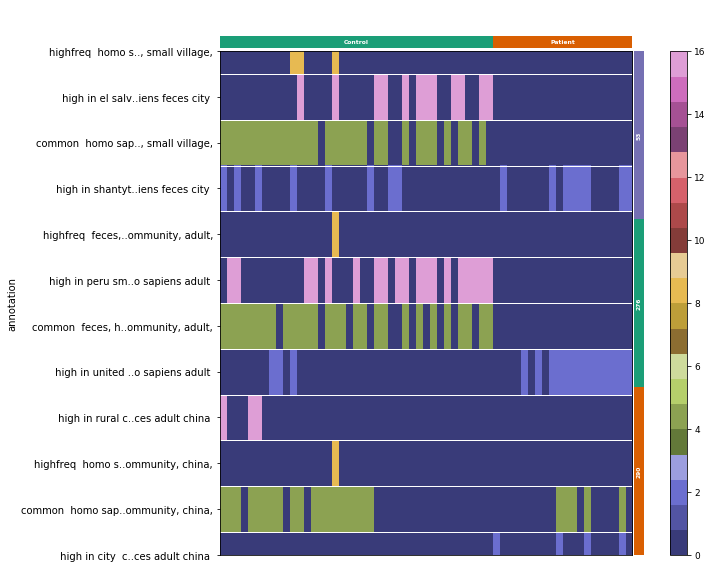

In [0]:
# get the two groups of bacteria and their names (higher in patient, higher in control)
groups = dd.feature_metadata._calour_diff_abundance_group.unique()
g1features = []
g2features = []
g1name = groups[0]
g2name = groups[1]
for cfeature in dd.feature_metadata.index.values:
    if dd.feature_metadata._calour_diff_abundance_group[cfeature] == g1name:
        g1features.append(cfeature)
    if dd.feature_metadata._calour_diff_abundance_group[cfeature] == g2name:
        g2features.append(cfeature)

# plot the term heatmap
term_annotations = db.show_term_details('small village', dd, g1features, g2features, group1_name=g1name, group2_name=g2name, gui='jupyter')

We want to see all the annotations where a given term appears, and see what bacteria from either group (Control and Patient) appear in that annotations. 

The diagram is showing us there are servel differences between patient and control group. The three annotion types("highfrq homo s, small village" "highfrq,...ommunity,adult" ,and "highfrq homo s ...ommunity, china") completely appear in control group only compared to patient group. Similarly, there is a high value and also occured only in control group ,which are "high in ei salv ..lens feces city" "high in peru sm..o sapaiens adult" "high in rural c.. ces adult china". However, some annotation types occured in the same level in both control and patient group that are "high in shantyt..iens feces city" and "high in united ..0 sapien adult".

## wordcloud for all the bacteria in the experiment

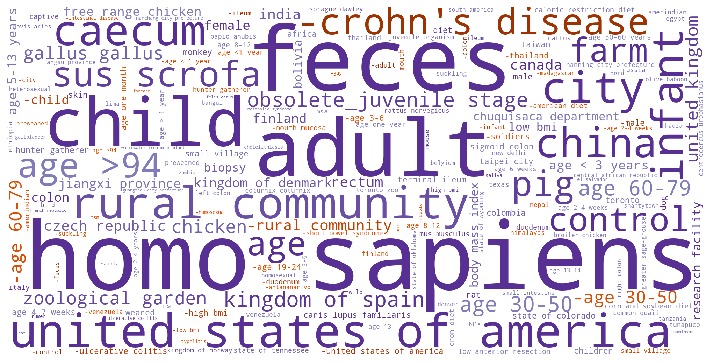

In [0]:
fig=db.draw_wordcloud(dat)

## and wordclouds for the bacteria higher in Patients/Controls

Control
Patient


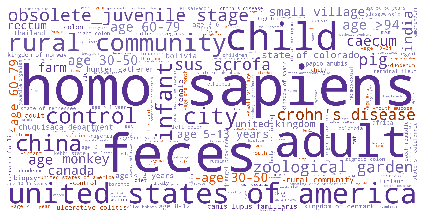

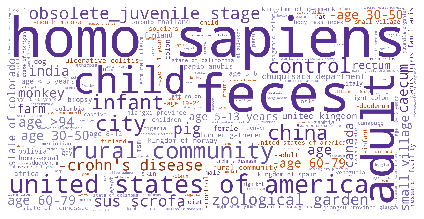

In [0]:
groups = dd.feature_metadata._calour_direction.unique()
g1features = []
g2features = []
g1name = groups[0]
g2name = groups[1]
for cfeature in dd.feature_metadata.index.values:
    if dd.feature_metadata._calour_direction[cfeature] == g1name:
        g1features.append(cfeature)
    if dd.feature_metadata._calour_direction[cfeature] == g2name:
        g2features.append(cfeature)

%matplotlib inline
print(g1name)
fig=db.draw_wordcloud(dd, g1features)
print(g2name)
fig=db.draw_wordcloud(dd, g2features)

## Classification

In [0]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold
from calour.training import plot_scatter, plot_roc, plot_cm
dat = ca.read_amplicon('/content/drive/My Drive/Colab Notebooks/data/cfs.biom','/content/drive/My Drive/Colab Notebooks/data/cfs.map.txt',
                       normalize=10000,min_reads=1000)
print(dat)

2019-12-01 13:31:13 WARNING These have metadata but do not have data - dropped: {'ERR1331814'}
AmpliconExperiment ("cfs.biom") with 87 samples, 2129 features


In [0]:
dat.sample_metadata['Subject'].value_counts()

Patient    48
Control    39
Name: Subject, dtype: int64

In [0]:
it = dat.classify('Subject', RandomForestClassifier(random_state=0), cv=RepeatedStratifiedKFold(5, 3), params=[{'n_estimators':3}, {'n_estimators': 500}])
res1 = next(it)
res1.count()

Control    261
Patient    261
Y_TRUE     261
SAMPLE     261
CV         261
dtype: int64

In [0]:
res1['Y_TRUE'].value_counts()

Patient    144
Control    117
Name: Y_TRUE, dtype: int64

In [0]:
res1['Control'].value_counts()

0.333333    92
0.666667    84
0.000000    50
1.000000    35
Name: Control, dtype: int64

In [0]:
res1['Patient'].value_counts()

0.666667    92
0.333333    84
1.000000    50
0.000000    35
Name: Patient, dtype: int64

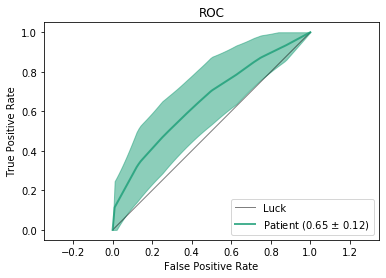

In [0]:

%matplotlib inline
plot_roc(res1,pos_label="Patient")

Accuracy = 0.615
F1score =  0.6280193236714975


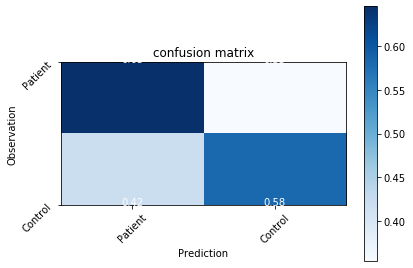

In [0]:

%matplotlib inline
plot_cm(res1 , normalize=True)
TP=0.65
TN=0.58
FP=0.35
FN=0.42
Precision = TP /( TP+FP)
Recall  = TP /( TP+FN)
F1score = 2*( (Precision*Recall ) / (Precision + Recall) )
print ("Accuracy =",(TP+TN)/(TP+TN+FP+FN) )
print("F1score = ", F1score)


Accuracy = (0.65+0.58)/(0.65+0.35+0.42+0.58) = 

In [0]:
res2 = next(it)
res2.count()

Control    261
Patient    261
Y_TRUE     261
SAMPLE     261
CV         261
dtype: int64

Accuracy = 0.705
F1score =  0.7255813953488373


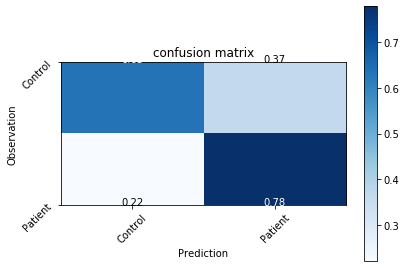

In [0]:
%matplotlib inline
plot_cm(res2 , normalize=True)
TP=0.78
TN=0.63
FP=0.37
FN=0.22
Precision = TP/(TP+FP)
Recall  = TP/(TP+FN)
F1score = 2*( (Precision*Recall ) / (Precision + Recall) )
print ("Accuracy =",(TP+TN)/(TP+TN+FP+FN) )
print("F1score = ", F1score)

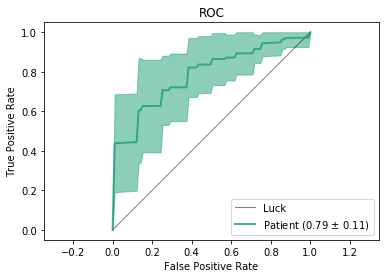

In [0]:

%matplotlib inline
plot_roc(res2,pos_label="Patient")